# Avaliação cross-dataset — VessMap, DRIVE, DCA1, OCTA2D

Este notebook agrega todos os resultados de zero-shot e few-shot dos 4 datasets em um
único DataFrame longo, gera tabelas-resumo e plots por dataset.

**Notas:**
- Zero-shot real disponível para VessMap e DRIVE; mockado (NaN) para DCA1 e OCTA2D.
- DRIVE não tem `from-scratch` (inferência ainda não rodada).
- Os dirs ignorados estão definidos em `utils_eval.DEFAULT_IGNORE_DIRS`.


## Legenda das nomenclaturas de modelos

Cada `model_type` codifica três informações: **arquitetura**, **origem dos pesos iniciais** e **regime de treino**.

| Label                  | Arquitetura            | Pesos iniciais          | Regime                  | Stage         |
|------------------------|------------------------|-------------------------|-------------------------|---------------|
| `UNet18`               | U-Net (encoder ResNet-18) | Aleatórios (Kaiming)   | Treino do zero          | `scratch`     |
| `UNet50`               | U-Net (encoder ResNet-50) | Aleatórios (Kaiming)   | Treino do zero          | `scratch`     |
| `VSUNet18`             | U-Net (encoder ResNet-18) | Pré-treinados em **VessShape** | Fine-tuning no dataset alvo | `finetune` |
| `VSUNet50`             | U-Net (encoder ResNet-50) | Pré-treinados em **VessShape** | Fine-tuning no dataset alvo | `finetune` |
| `IN-UNet18`            | U-Net (encoder ResNet-18) | Pré-treinados em **ImageNet** | Fine-tuning no dataset alvo | `finetune` |
| `IN-UNet50`            | U-Net (encoder ResNet-50) | Pré-treinados em **ImageNet** | Fine-tuning no dataset alvo | `finetune` |
| `LiteMedSAM-FT`        | LiteMedSAM (encoder ViT leve do MedSAM) | Pré-treinados em **MedSAM** (LiteMedSAM checkpoint) | Fine-tuning no dataset alvo | `finetune` |
| `Zero-Shot VSUNet18`   | U-Net (encoder ResNet-18) | Pré-treinados em **VessShape** | **Sem** fine-tuning — inferência direta | `zero_shot` |
| `Zero-Shot VSUNet50`   | U-Net (encoder ResNet-50) | Pré-treinados em **VessShape** | **Sem** fine-tuning — inferência direta | `zero_shot` |
| `... (mock)`           | —                      | —                       | Placeholder com `NaN`   | `zero_shot`   |

**Convenções:**
- `VS` = pré-treino em **VessShape** (dataset sintético próprio do projeto).
- `IN-` = pré-treino em **ImageNet**.
- `-FT` = fine-tuning a partir de checkpoint pré-treinado.
- `Zero-Shot` = nenhum fine-tuning no dataset alvo (`num_samples = 0`).
- Sufixo ` (mock)` = linha placeholder gerada por `utils_eval.generate_mock_zero_shot` quando o CSV de zero-shot real ainda não existe (DCA1 e OCTA2D); aparece com `NaN` em todas as métricas e é identificada por `is_mock=True`.

**Eixo de comparação do paper:**
- `UNet*` (scratch) vs `IN-UNet*` (ImageNet) vs `VSUNet*` (VessShape) → mede o ganho do pré-treino em VessShape sobre as alternativas.
- `Zero-Shot VSUNet*` em `num_samples = 0` → mede a transferência sem fine-tuning.
- `LiteMedSAM-FT` → baseline de modelo de segmentação médica de larga escala.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils_eval import (
    load_all_datasets,
    build_summary_table,
    default_line_styles_7way,
    METRICS,
    RESULTS_DIR,
    FIGURES_DIR,
    ensure_output_dirs,
)

ensure_output_dirs()
from utils import plot_mean_dice_score

## 1. Carregar todos os datasets

In [2]:
frames = load_all_datasets(
    datasets=['vessmap', 'drive', 'dca1', 'octa2d'],
    root='..',
    mock_zero_shot=True,  # só aplica onde não há CSV real
)
for ds, df in frames.items():
    print(f'{ds:8s} -> shape={df.shape}, model_types={sorted(df["model_type"].unique())}')

vessmap  -> shape=(1107, 17), model_types=['IN-UNet18', 'IN-UNet50', 'LiteMedSAM-FT', 'UNet18', 'UNet50', 'VSUNet18', 'VSUNet50', 'Zero-Shot IN-UNet18', 'Zero-Shot IN-UNet50', 'Zero-Shot LiteMedSAM', 'Zero-Shot VSUNet18', 'Zero-Shot VSUNet50']
drive    -> shape=(680, 17), model_types=['IN-UNet18', 'IN-UNet50', 'LiteMedSAM-FT', 'VSUNet18', 'VSUNet50', 'Zero-Shot IN-UNet18', 'Zero-Shot IN-UNet50', 'Zero-Shot LiteMedSAM', 'Zero-Shot VSUNet18', 'Zero-Shot VSUNet50']
dca1     -> shape=(1002, 17), model_types=['IN-UNet18', 'IN-UNet50', 'LiteMedSAM-FT', 'UNet18', 'UNet50', 'VSUNet18', 'VSUNet50', 'Zero-Shot IN-UNet18', 'Zero-Shot IN-UNet50', 'Zero-Shot LiteMedSAM', 'Zero-Shot VSUNet18', 'Zero-Shot VSUNet50']
octa2d   -> shape=(1158, 17), model_types=['IN-UNet18', 'IN-UNet50', 'LiteMedSAM-FT', 'UNet18', 'UNet50', 'VSUNet18', 'VSUNet50', 'Zero-Shot IN-UNet18', 'Zero-Shot IN-UNet50', 'Zero-Shot LiteMedSAM', 'Zero-Shot VSUNet18', 'Zero-Shot VSUNet50']


In [3]:
df_all = pd.concat(
    [f.assign(dataset=ds) for ds, f in frames.items()],
    ignore_index=True,
)
df_all.to_csv(os.path.join(RESULTS_DIR, 'cross_dataset_long.csv'), index=False)
print('df_all shape:', df_all.shape)
df_all.head(3)

df_all shape: (3947, 18)


,run_name,num_samples,run,rep,wandb_group,model_class,Accuracy,IoU,Precision,Recall,Dice,AUC,model_type,stage,experiment,is_mock,weights,dataset
0,resnet18_unet_weights_id:FromScratch_run:1_rep...,1,1,1,resnet18_unet | lr:1e-2 | weights_id:FromScrat...,resnet18_unet,0.229596,0.229475,0.229475,1.000000,0.366875,0.613825,UNet18,scratch,multi_train_scratch_vessmap_unet18_lr_e-2,False,None,vessmap
1,resnet18_unet_weights_id:FromScratch_run:1_rep...,10,1,1,resnet18_unet | lr:1e-2 | weights_id:FromScrat...,resnet18_unet,0.876599,0.657001,0.767141,0.843215,0.783581,0.963830,UNet18,scratch,multi_train_scratch_vessmap_unet18_lr_e-2,False,None,vessmap
2,resnet18_unet_weights_id:FromScratch_run:1_rep...,12,1,1,resnet18_unet | lr:1e-2 | weights_id:FromScrat...,resnet18_unet,0.894967,0.686698,0.750673,0.888806,0.806571,0.959009,UNet18,scratch,multi_train_scratch_vessmap_unet18_lr_e-2,False,None,vessmap


## 2. Cobertura cross-dataset

In [4]:
coverage = (df_all
            .groupby(['dataset','model_type','stage'])
            .size()
            .rename('n_runs')
            .reset_index())
coverage_wide = coverage.pivot_table(
    index=['model_type','stage'], columns='dataset', values='n_runs', fill_value=0
)
coverage_wide.to_csv(os.path.join(RESULTS_DIR, 'cross_dataset_coverage.csv'))
coverage_wide

,dataset,dca1,drive,octa2d,vessmap
model_type,stage,,,,
IN-UNet18,finetune,165.0,135.0,165.0,165.0
IN-UNet50,finetune,165.0,135.0,164.0,165.0
LiteMedSAM-FT,finetune,165.0,135.0,164.0,165.0
UNet18,scratch,82.0,0.0,165.0,135.0
UNet50,scratch,90.0,0.0,165.0,143.0
VSUNet18,finetune,165.0,135.0,165.0,165.0
VSUNet50,finetune,165.0,135.0,165.0,164.0
Zero-Shot IN-UNet18,zero_shot,1.0,1.0,1.0,1.0
Zero-Shot IN-UNet50,zero_shot,1.0,1.0,1.0,1.0


## 3. Resumos por dataset (mean ± std)

In [5]:
SAMPLE_FILTERS = {
    'vessmap': [0, 1, 20],
    'drive':   [0, 1, 16],
    'dca1':    [0, 1, 20],
    'octa2d':  [0, 1, 20],
}
summaries = []
for ds, df in frames.items():
    s = build_summary_table(df, sample_filter=SAMPLE_FILTERS[ds])
    s.insert(0, 'dataset', ds)
    summaries.append(s)
summary_all = pd.concat(summaries, ignore_index=True)
summary_all.to_csv(os.path.join(RESULTS_DIR, 'cross_dataset_summary.csv'), index=False)
summary_all

,dataset,model_type,num_samples,mean_Accuracy,std_Accuracy,mean_IoU,std_IoU,mean_Precision,std_Precision,mean_Recall,std_Recall,mean_Dice,std_Dice,mean_AUC,std_AUC
0,vessmap,IN-UNet18,1,0.651133,0.154921,0.357602,0.078854,0.586141,0.187395,0.660827,0.179978,0.485583,0.082485,0.781195,0.086924
1,vessmap,IN-UNet18,20,0.922932,0.010348,0.713157,0.036758,0.863449,0.030091,0.811081,0.061219,0.822028,0.029491,0.965223,0.005488
2,vessmap,IN-UNet50,1,0.666781,0.223678,0.402879,0.090024,0.627195,0.225403,0.711557,0.168689,0.534322,0.086542,0.840877,0.039321
3,vessmap,IN-UNet50,20,0.932008,0.009469,0.740701,0.016660,0.884297,0.031945,0.821307,0.038949,0.841621,0.014071,0.969103,0.003391
4,vessmap,LiteMedSAM-FT,1,0.754637,0.213352,0.458689,0.125835,0.690520,0.214464,0.671937,0.168473,0.581172,0.117465,0.833197,0.131980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,octa2d,Zero-Shot IN-UNet18,0,0.863412,NaN,0.074710,NaN,0.153186,NaN,0.141695,NaN,0.138425,NaN,0.586518,NaN
66,octa2d,Zero-Shot IN-UNet50,0,0.090859,NaN,0.082132,NaN,0.082208,NaN,0.988930,NaN,0.151281,NaN,0.447949,NaN
67,octa2d,Zero-Shot LiteMedSAM,0,0.917757,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.613049,NaN
68,octa2d,Zero-Shot VSUNet18,0,0.906988,NaN,0.179097,NaN,0.703621,NaN,0.350771,NaN,0.272441,NaN,0.782416,NaN


## 4. Plots por dataset

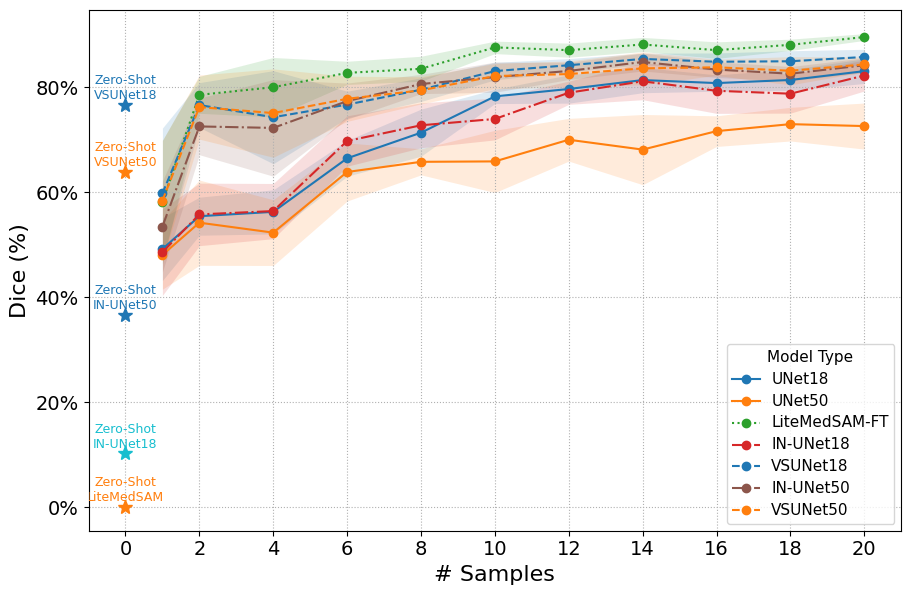

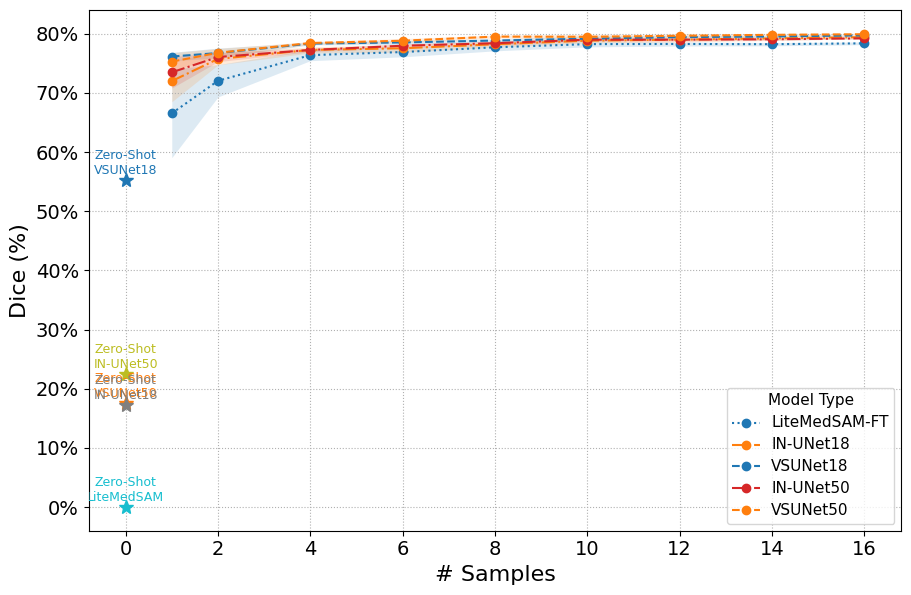

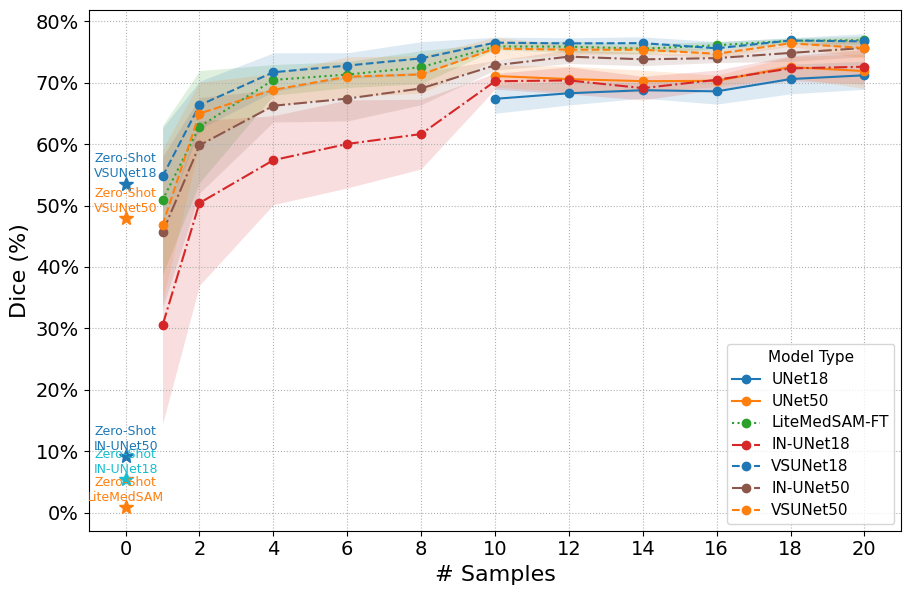

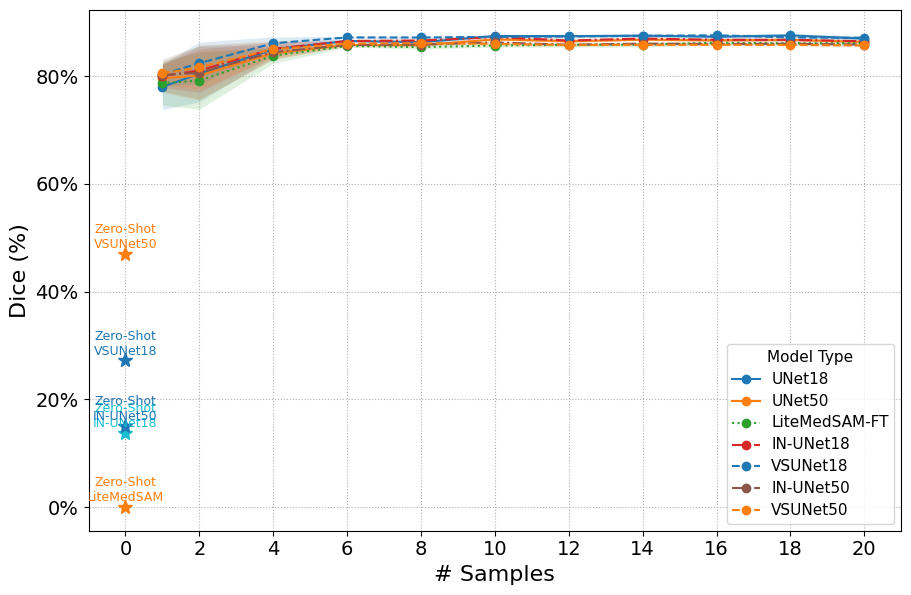

In [6]:
PRETTY = {'vessmap': 'VessMap', 'drive': 'DRIVE', 'dca1': 'DCA1', 'octa2d': 'OCTA2D'}
line_styles = default_line_styles_7way()

for ds, df in frames.items():
    plot_mean_dice_score(
        df,
        dataset_name=PRETTY[ds],
        hue='model_type',
        x_data='num_samples',
        y_data='Dice',
        line_styles=line_styles,
        annotate_zero_shot=True,
        title='',
        legend_title='Model Type',
        xlabel='# Samples',
        percentage=True,
        save_path=os.path.join(FIGURES_DIR, f'cross_dataset_{ds}.svg'),
        font_sizes={
            'title': 16, 'xlabel': 16, 'ylabel': 16,
            'xaxis': 14, 'yaxis': 14,
            'legend': 11, 'zero_shot_annotation': 9, 'zero_shot_marker': 10,
        },
        figsize=(9, 6),
        legend_loc='lower right',
        share_zero_shot_color_with='finetuned',
    )

## 5. Top-line — melhor model_type em N=1 e em N máximo (por dataset)

In [7]:
top_rows = []
for ds, df in frames.items():
    if df.empty:
        continue
    df_ft = df[df['stage'] != 'zero_shot']
    if df_ft.empty:
        continue
    n_max = int(df_ft['num_samples'].max())
    for n in [1, n_max]:
        snap = (df_ft[df_ft['num_samples'] == n]
                .groupby('model_type')['Dice']
                .agg(['mean','std','count'])
                .reset_index()
                .sort_values('mean', ascending=False))
        if snap.empty:
            continue
        best = snap.iloc[0]
        top_rows.append({
            'dataset': ds,
            'num_samples': n,
            'best_model_type': best['model_type'],
            'mean_Dice': best['mean'],
            'std_Dice': best['std'],
            'n_runs': int(best['count']),
        })
topline = pd.DataFrame(top_rows)
topline.to_csv(os.path.join(RESULTS_DIR, 'cross_dataset_topline.csv'), index=False)
topline

,dataset,num_samples,best_model_type,mean_Dice,std_Dice,n_runs
0,vessmap,1,VSUNet18,0.597460,0.124416,15
1,vessmap,20,LiteMedSAM-FT,0.895343,0.006437,15
2,drive,1,VSUNet18,0.761387,0.007053,15
3,drive,16,VSUNet50,0.799093,0.000811,15
4,dca1,1,VSUNet18,0.547335,0.079107,15
5,dca1,20,LiteMedSAM-FT,0.769361,0.006627,15
6,octa2d,1,VSUNet50,0.805284,0.020924,15
7,octa2d,20,VSUNet18,0.871247,0.002918,15


## 6. Bar chart — Dice@N=1 cross-dataset (foco few-shot)

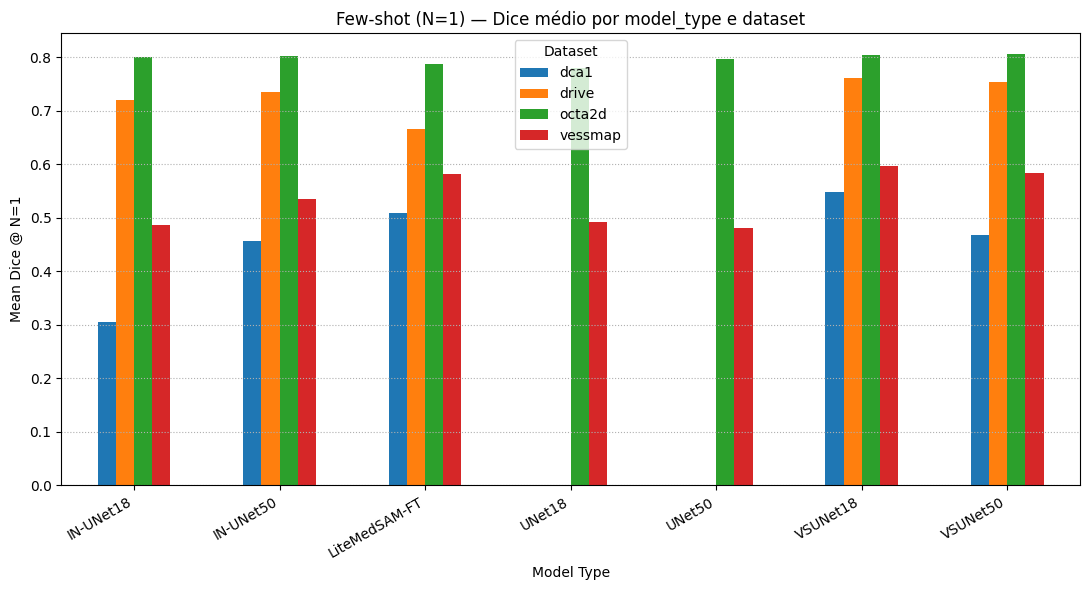

In [8]:
n1 = (df_all[(df_all['num_samples'] == 1) & (df_all['stage'] != 'zero_shot')]
      .groupby(['dataset','model_type'])['Dice']
      .mean()
      .reset_index())
if n1.empty:
    print('Sem dados para num_samples=1.')
else:
    pivot = n1.pivot(index='model_type', columns='dataset', values='Dice')
    fig, ax = plt.subplots(figsize=(11, 6))
    pivot.plot(kind='bar', ax=ax)
    ax.set_ylabel('Mean Dice @ N=1')
    ax.set_xlabel('Model Type')
    ax.set_title('Few-shot (N=1) — Dice médio por model_type e dataset')
    ax.legend(title='Dataset')
    ax.grid(True, axis='y', linestyle=':')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'cross_dataset_dice_at_n1.svg'), bbox_inches='tight')
    plt.show()
    pivot

## 7. Bar chart + tabela — Dice@N=0 cross-dataset (zero-shot)

In [ ]:
zs_real = (df_all[
    (df_all['num_samples'] == 0) &
    (df_all['stage'] == 'zero_shot') &
    (~df_all['is_mock'])
]
.groupby(['dataset', 'model_type'])['Dice']
.mean()
.reset_index())

if zs_real.empty:
    print('Sem dados zero-shot reais disponíveis.')
else:
    pivot_zs = zs_real.pivot(index='model_type', columns='dataset', values='Dice')
    pivot_zs = pivot_zs.sort_values(pivot_zs.columns[0], ascending=False)

    fig, ax = plt.subplots(figsize=(11, 5))
    pivot_zs.plot(kind='bar', ax=ax)
    ax.set_ylabel('Mean Dice @ N=0')
    ax.set_xlabel('Model Type')
    ax.set_title('Zero-shot — Dice médio por model_type e dataset')
    ax.legend(title='Dataset')
    ax.grid(True, axis='y', linestyle=':')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'cross_dataset_dice_at_n0_zeroshot.svg'), bbox_inches='tight')
    plt.show()
    pivot_zs

## 8. Validação Estatística — Wilcoxon signed-rank (fine-tuned vs zero-shot, por dataset × N)

Para cada modelo refinado (stage `finetune`) que possui uma contraparte zero-shot, testamos se o
fine-tuning com N amostras produz Dice **estatisticamente superior** ao baseline zero-shot do mesmo
modelo no mesmo dataset.

**Metodologia:**

- **Dados**: métricas por imagem (`{ds}_all_results_per_image.csv`) — uma linha por imagem de teste
  por run. Quando há múltiplas repetições para um mesmo N, calculamos a média do Dice por imagem
  antes do teste para evitar pseudoreplicação.
- **Teste**: Wilcoxon signed-rank unilateral (H₁: fine-tuned > zero-shot), pareado por imagem
  (mesmo conjunto de teste). Escolhemos Wilcoxon por ser não-paramétrico e robusto a distribuições
  assimétricas de Dice. Requer ≥ 5 imagens em comum para ser executado.
- **Limiar**: α = 0,05. Células marcadas com **1** indicam melhora significativa sobre o zero-shot;
  **0** indica ausência de evidência estatística; cinza indica dados insuficientes (NaN).
- **Modelos avaliados**: VSUNet18, VSUNet50, IN-UNet18, IN-UNet50, LiteMedSAM-FT — apenas os que
  possuem contraparte zero-shot para comparação direta.

In [ ]:
import seaborn as sns
from scipy import stats

ALPHA = 0.05
FINE_TUNED_TO_ZEROSHOT = {
    'VSUNet18':      'Zero-Shot VSUNet18',
    'VSUNet50':      'Zero-Shot VSUNet50',
    'IN-UNet18':     'Zero-Shot IN-UNet18',
    'IN-UNet50':     'Zero-Shot IN-UNet50',
    'LiteMedSAM-FT': 'Zero-Shot LiteMedSAM',
}
DATASETS_ORDER = ['dca1', 'drive', 'octa2d', 'vessmap']

# Load pre-saved per-image CSVs
per_image = {
    ds: pd.read_csv(os.path.join(RESULTS_DIR, f'{ds}_all_results_per_image.csv'))
    for ds in DATASETS_ORDER
}

sig_matrices = {}

for ft_model, zs_model in FINE_TUNED_TO_ZEROSHOT.items():
    rows = {}
    all_ns = set()
    for ds, df_pi in per_image.items():
        # Zero-shot per-image (real, not mock)
        zs_df = df_pi[(df_pi['model_type'] == zs_model) & (~df_pi['is_mock'])]
        if zs_df.empty:
            continue
        zs_by_img = zs_df.groupby('image')['Dice'].mean()

        ns_vals = sorted(df_pi[
            (df_pi['model_type'] == ft_model) & (df_pi['stage'] == 'finetune')
        ]['num_samples'].unique())
        all_ns.update(ns_vals)

        row = {}
        for n in ns_vals:
            ft_df = df_pi[
                (df_pi['model_type'] == ft_model) &
                (df_pi['num_samples'] == n) &
                (df_pi['stage'] == 'finetune')
            ]
            if ft_df.empty:
                row[n] = np.nan
                continue
            ft_by_img = ft_df.groupby('image')['Dice'].mean()
            common = ft_by_img.index.intersection(zs_by_img.index)
            if len(common) < 5:
                row[n] = np.nan
                continue
            ft_vals = ft_by_img[common].values
            zs_vals = zs_by_img[common].values
            if (ft_vals == zs_vals).all():
                row[n] = 0
                continue
            _, p = stats.wilcoxon(ft_vals, zs_vals, alternative='greater')
            row[n] = 1 if p < ALPHA else 0
        rows[ds] = row

    if rows:
        ns_ordered = sorted(all_ns)
        sig_matrices[ft_model] = (
            pd.DataFrame(rows, index=ns_ordered).T.reindex(DATASETS_ORDER)
        )

n_models = len(sig_matrices)
ncols = 3
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 4))
axes_flat = axes.flatten()

for idx, (ft_model, mat) in enumerate(sig_matrices.items()):
    ax = axes_flat[idx]
    sns.heatmap(
        mat.astype(float), ax=ax, cmap='Blues', vmin=0, vmax=1,
        annot=True, fmt='g', linewidths=0.5, cbar=False, linecolor='lightgray'
    )
    ax.set_title(ft_model, fontsize=11)
    ax.set_xlabel('N amostras')
    ax.set_ylabel('Dataset')

for j in range(n_models, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle(
    f'Dice(fine-tuned @ N) > Dice(zero-shot) — Wilcoxon signed-rank (α={ALPHA})\n'
    '1 = significativo, 0 = não significativo',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'statistical_significance_wilcoxon.svg'), bbox_inches='tight')
plt.show()